# Phase 2 - Clustering Implementation

This notebook applies KMeans and DBSCAN clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Dataset/clean_data.csv", low_memory=False)
df.head()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science,Total_Activity,Sleep_Study_Ratio,Activity_Per_Hour,Sleep_Deficit
0,0.536144,1.0856771329663695,0.289788,-0.861956,-0.093125,0.911792,0.751322,False,True,False,False,False,False,False,True,-0.719460,0.821735,-0.622490,-0.265947
1,-0.457414,-0.24804789297862226,-1.105638,1.296600,1.749418,1.558063,-1.846436,False,False,True,False,False,True,False,False,1.919321,-1.278335,1.566238,1.111099
2,-0.457414,0.2905773726943039,-1.198106,-1.747063,-1.226997,1.442658,-0.677106,False,False,True,False,False,False,True,False,-2.495744,1.381698,-3.060133,1.198436
3,0.053420,1.2764531464032722,0.786877,-2.065771,0.757279,1.281090,-0.677106,False,False,True,False,False,True,False,False,-0.775821,2.763078,-0.685405,-0.784305
4,-0.999528,0.5143916680891795,-0.054223,-1.456105,0.544678,-1.627130,1.240533,False,False,True,True,False,False,False,False,-0.608900,1.445965,-0.501439,0.084051


In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87141 entries, 0 to 87140
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     87141 non-null  float64
 1   CGPA                    87141 non-null  str    
 2   Sleep_Duration          87141 non-null  float64
 3   Study_Hours             87141 non-null  float64
 4   Social_Media_Hours      87141 non-null  float64
 5   Physical_Activity       87141 non-null  float64
 6   Stress_Level            87141 non-null  float64
 7   Depression              87141 non-null  bool   
 8   Gender_Female           87141 non-null  bool   
 9   Gender_Male             87141 non-null  bool   
 10  Department_Arts         87141 non-null  bool   
 11  Department_Business     87141 non-null  bool   
 12  Department_Engineering  87141 non-null  bool   
 13  Department_Medical      87141 non-null  bool   
 14  Department_Science      87141 non-null  bool   
 

In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Keep only numeric columns
df_model = df.select_dtypes(include=np.number)

# Remove missing values if any
df_model = df_model.dropna()

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(df_model)
print(df_model.shape)

(87141, 10)


## Clustering Algorithm Selection & Justification

We selected KMeans and DBSCAN for clustering.

**KMeans** was chosen because it is efficient and works well with large datasets and spherical-shaped clusters. It is also easy to interpret.

**DBSCAN** was selected because it can detect arbitrary-shaped clusters and handle noise/outliers, which is useful for real-world student behavior data where patterns are not always clearly separated.

The dataset contains mixed behavioral features (study hours, sleep, stress), making it suitable for both centroid-based and density-based clustering approaches.

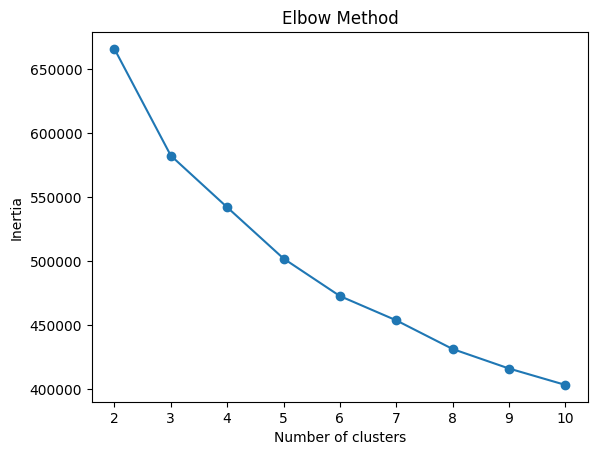

In [5]:
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.savefig("Elbow_plot.png")
plt.show()

In [6]:
# Keep numeric data + clean
df_model = df.select_dtypes(include=np.number).dropna()

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(df_model)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# Add cluster to original dataframe (aligned)
df = df.dropna().reset_index(drop=True)
df['Cluster_KMeans'] = labels_kmeans

In [7]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

df['Cluster_DBSCAN'] = labels_dbscan
print(np.unique(labels_dbscan))

[-1  0]


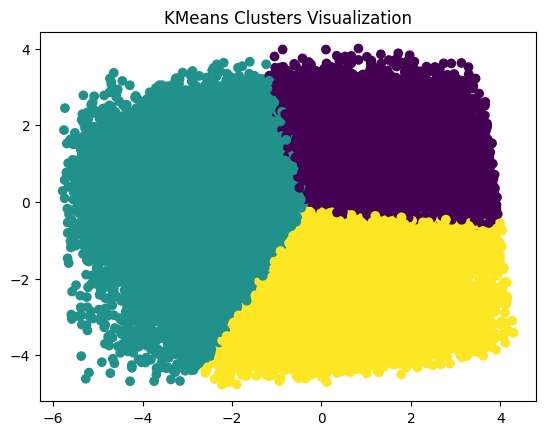

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
plt.title("KMeans Clusters Visualization")
plt.savefig("kmeans_plot.png")
plt.show()

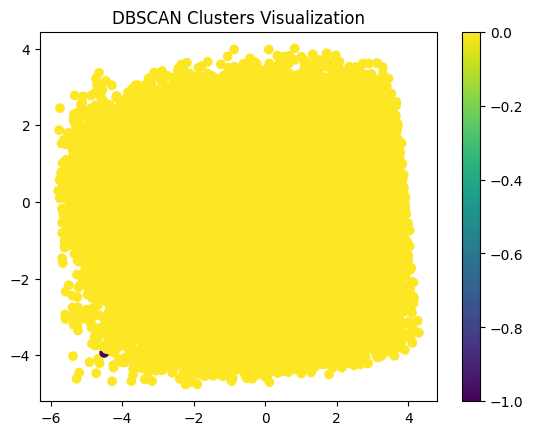

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='viridis')
plt.title("DBSCAN Clusters Visualization")
plt.colorbar()
plt.savefig("dbscan_plot.png")
plt.show()

In [10]:
df.to_csv("clustering_results.csv", index=False)

## Evaluation & Metrics

In [11]:
import seaborn as sns  # for heatmap visualization
import os              # for creating folders

from sklearn.metrics import (
    silhouette_score,    # average silhouette across all points
    silhouette_samples,  # silhouette score per individual point in plot
    davies_bouldin_score # Davies-Bouldin Index
)

# Create folders to save results and plots into
os.makedirs('Unsupervised_Learning/clustering_results', exist_ok=True)
os.makedirs('Unsupervised_Learning/plots', exist_ok=True)

# Save the Depression column as ground truth before losing it
# Convert True/False to 1/0 so math works on it later
# .reset_index(drop=True) makes sure the row numbers are clean (0,1,2,3...)
ground_truth = df['Depression'].astype(int).reset_index(drop=True)

print("Depression label distribution:")
print(ground_truth.value_counts())

Depression label distribution:
Depression
0    78738
1     8403
Name: count, dtype: int64


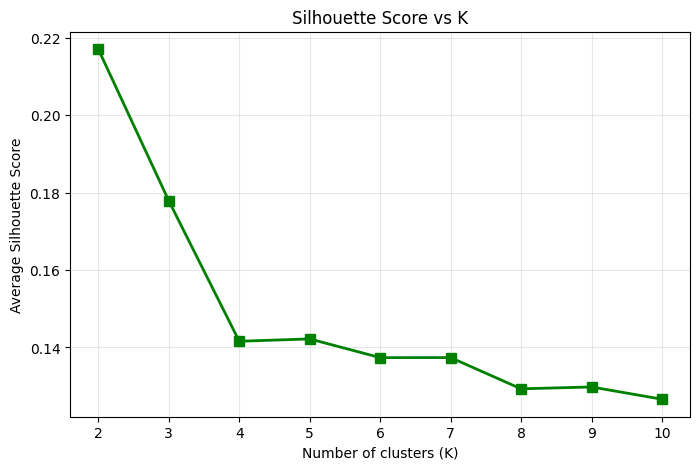

Best K by silhouette: 2  (score = 0.2171)
Silhouette at K=3: 0.1779


In [12]:
K_range = range(2, 11)   
sil_values = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=3)
    lbl = km.fit_predict(X)
    
    # sample only 5000 points to increase speed
    sil_values.append(silhouette_score(X, lbl, sample_size=5000, random_state=42))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), sil_values, 'gs-', linewidth=2, markersize=7)
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.grid(alpha=0.3)
plt.savefig('Unsupervised_Learning/plots/silhouette_k_selection.png', dpi=150)
plt.show()

best_k = list(K_range)[np.argmax(sil_values)]
print(f'Best K by silhouette: {best_k}  (score = {max(sil_values):.4f})')
print(f'Silhouette at K=3: {sil_values[1]:.4f}')

## K Selection Justification

Although the silhouette analysis identifies K=2 as mathematically optimal (score = 0.2171),
K=3 was selected because it provides more actionable student profiles for the advice system.
A binary split offers no additional insight beyond the existing Depression label, whereas
three clusters allow the system to distinguish nuanced risk levels among students
(e.g. high risk, medium risk, low risk).

The silhouette score at K=3 (0.1779) remains acceptable, and the elbow plot confirms
that WCSS improvement beyond K=3 is minimal, further supporting this choice.

In [13]:
# KMeans metrics
sil_kmeans  = silhouette_score(X, labels_kmeans)
dbi_kmeans  = davies_bouldin_score(X, labels_kmeans)
wcss_kmeans = kmeans.inertia_  # already computed during fit

print('KMeans (K=3)')
print(f'  Silhouette Score     : {sil_kmeans:.4f}  (higher is better, max=1)')
print(f'  Davies-Bouldin Index : {dbi_kmeans:.4f}  (lower is better, min=0)')
print(f'  WCSS                 : {wcss_kmeans:.2f}')

# ── DBSCAN metrics ─────────────────────────────────────────────────────────────
n_noise       = np.sum(labels_dbscan == -1)   # count points labeled as noise
n_db_clusters = len(set(labels_dbscan)) - 1   # subtract 1 to exclude the -1 noise label
noise_ratio   = n_noise / len(labels_dbscan)  # what fraction of data is noise

# Only compute silhouette/DBI on the non-noise points
mask_core = labels_dbscan != -1  # True for every point that's not noise

if n_db_clusters >= 2:
    # These metrics need at least 2 clusters to compare
    sil_dbscan = silhouette_score(X[mask_core], labels_dbscan[mask_core])
    dbi_dbscan = davies_bouldin_score(X[mask_core], labels_dbscan[mask_core])
else:
    # DBSCAN only found 1 real cluster, so metrics can't be computed
    sil_dbscan = float('nan')
    dbi_dbscan = float('nan')
    print('\nNote: DBSCAN found only 1 cluster, silhouette and DBI require at least 2.')

print('\nDBSCAN')
print(f'  Effective clusters   : {n_db_clusters}')
print(f'  Noise points         : {n_noise} ({noise_ratio:.1%} of data)')
print(f'  Silhouette Score     : {sil_dbscan}')
print(f'  Davies-Bouldin Index : {dbi_dbscan}')

KMeans (K=3)
  Silhouette Score     : 0.1714  (higher is better, max=1)
  Davies-Bouldin Index : 1.7545  (lower is better, min=0)
  WCSS                 : 582560.27

Note: DBSCAN found only 1 cluster, silhouette and DBI require at least 2.

DBSCAN
  Effective clusters   : 1
  Noise points         : 2 (0.0% of data)
  Silhouette Score     : nan
  Davies-Bouldin Index : nan


In [14]:
def bcubed_precision_recall(labels_true, labels_pred):
    """
    Computes BCubed Precision, Recall, and F1.
    labels_true = real Depression labels (0 or 1)
    labels_pred = cluster assignments from KMeans or DBSCAN
    Noise points (label == -1 in DBSCAN) are excluded.
    """
    # Exclude noise points — they don't belong to any cluster
    mask = labels_pred != -1
    lt = np.array(labels_true)[mask]   # ground truth for non-noise points
    lp = np.array(labels_pred)[mask]   # cluster labels for non-noise points
    n  = len(lt)

    precision_sum = 0.0
    recall_sum    = 0.0

    for i in range(n):
        # Which points are in the same cluster as point i?
        same_cluster = lp == lp[i]
        # Which points have the same true label as point i?
        same_class   = lt == lt[i]

        # Precision for i: how many cluster-mates share my label?
        precision_sum += (same_cluster & same_class).sum() / same_cluster.sum()

        # Recall for i: how many people with my label are in my cluster?
        recall_sum    += (same_cluster & same_class).sum() / same_class.sum()

    precision = precision_sum / n
    recall    = recall_sum / n
    # F1: harmonic mean of precision and recall
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


gt = ground_truth.values  # convert to numpy array

bc_p_km, bc_r_km, bc_f1_km = bcubed_precision_recall(gt, labels_kmeans)
bc_p_db, bc_r_db, bc_f1_db = bcubed_precision_recall(gt, labels_dbscan)

# Print as a clean table
print(f"{'Algorithm':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"{'KMeans':<12} {bc_p_km:>10.4f} {bc_r_km:>10.4f} {bc_f1_km:>10.4f}")
print(f"{'DBSCAN':<12} {bc_p_db:>10.4f} {bc_r_db:>10.4f} {bc_f1_db:>10.4f}")

Algorithm     Precision     Recall         F1
KMeans           0.8258     0.3430     0.4847
DBSCAN           0.8257     1.0000     0.9046


In [15]:
summary = pd.DataFrame({
    'Algorithm'        : ['KMeans', 'DBSCAN'],
    'N_Clusters'       : [3, n_db_clusters],
    'Silhouette_Score' : [round(sil_kmeans, 4), sil_dbscan],
    'Davies_Bouldin'   : [round(dbi_kmeans, 4), dbi_dbscan],
    'WCSS'             : [round(wcss_kmeans, 2), 'N/A'],   # DBSCAN has no WCSS
    'Noise_Ratio'      : ['0%', f'{noise_ratio:.1%}'],     # KMeans has no noise
    'BCubed_Precision' : [round(bc_p_km, 4), round(bc_p_db, 4)],
    'BCubed_Recall'    : [round(bc_r_km, 4), round(bc_r_db, 4)],
    'BCubed_F1'        : [round(bc_f1_km, 4), round(bc_f1_db, 4)],
})

print(summary.to_string(index=False))

# Save to file so it appears in the repo under clustering_results/
summary.to_csv('Unsupervised_Learning/clustering_results/metrics_comparison.csv', index=False)
print('\nSaved → Unsupervised_Learning/clustering_results/metrics_comparison.csv')

Algorithm  N_Clusters  Silhouette_Score  Davies_Bouldin       WCSS Noise_Ratio  BCubed_Precision  BCubed_Recall  BCubed_F1
   KMeans           3            0.1714          1.7545  582560.27          0%            0.8258          0.343     0.4847
   DBSCAN           1               NaN             NaN        N/A        0.0%            0.8257          1.000     0.9046

Saved → Unsupervised_Learning/clustering_results/metrics_comparison.csv


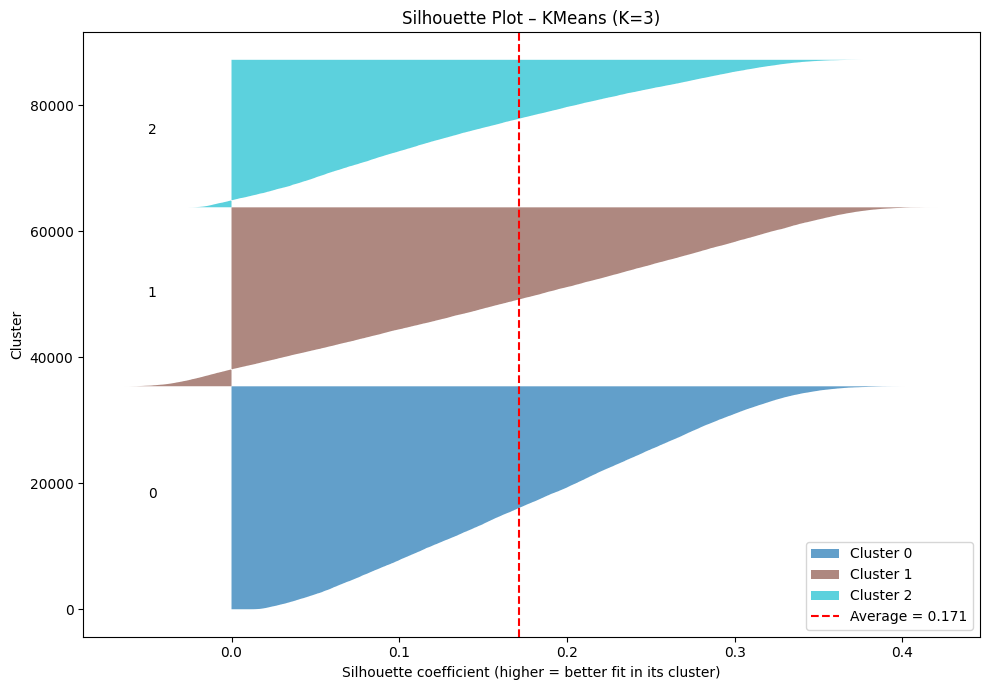

In [16]:
# Compute silhouette score for every individual point
sample_sil = silhouette_samples(X, labels_kmeans)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10  # starting y position for the first cluster's bar
colors = plt.cm.tab10(np.linspace(0, 1, 3))  # 3 distinct colors for 3 clusters

for i in range(3):
    # Get silhouette values for cluster i, sorted smallest to largest
    vals = np.sort(sample_sil[labels_kmeans == i])
    y_upper = y_lower + len(vals)

    # Fill a horizontal band — wider = more points, further right = higher score
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')

    # Label the cluster number in the middle of its band
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))

    y_lower = y_upper + 10  # leave a small gap before next cluster

# Red dashed line = average silhouette score
ax.axvline(x=sil_kmeans, color='red', linestyle='--',
           label=f'Average = {sil_kmeans:.3f}')

ax.set_title('Silhouette Plot – KMeans (K=3)')
ax.set_xlabel('Silhouette coefficient (higher = better fit in its cluster)')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig('Unsupervised_Learning/plots/silhouette_plot_kmeans.png', dpi=150)
plt.show()

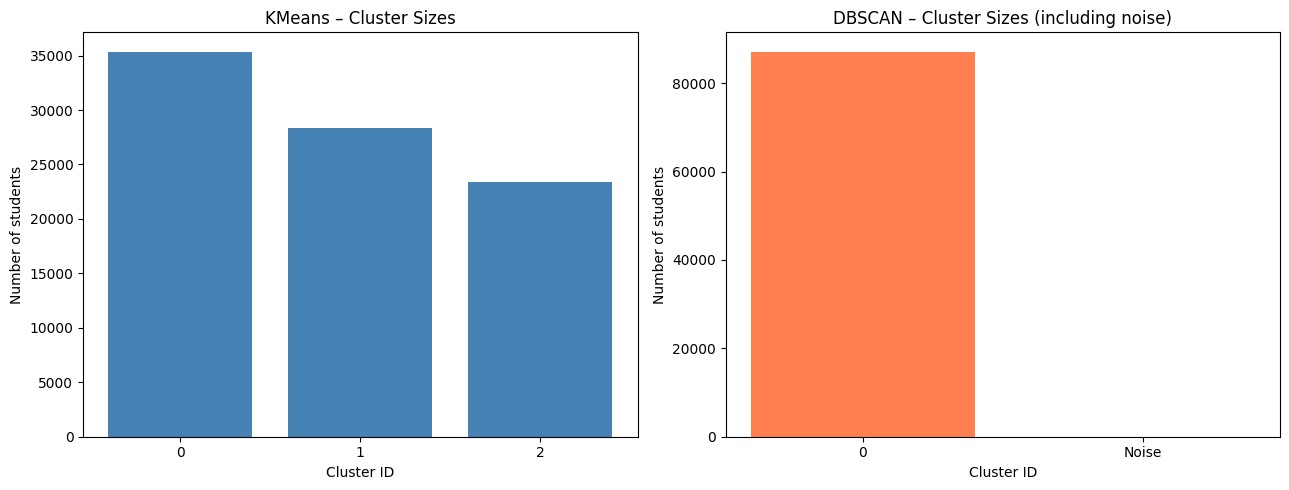

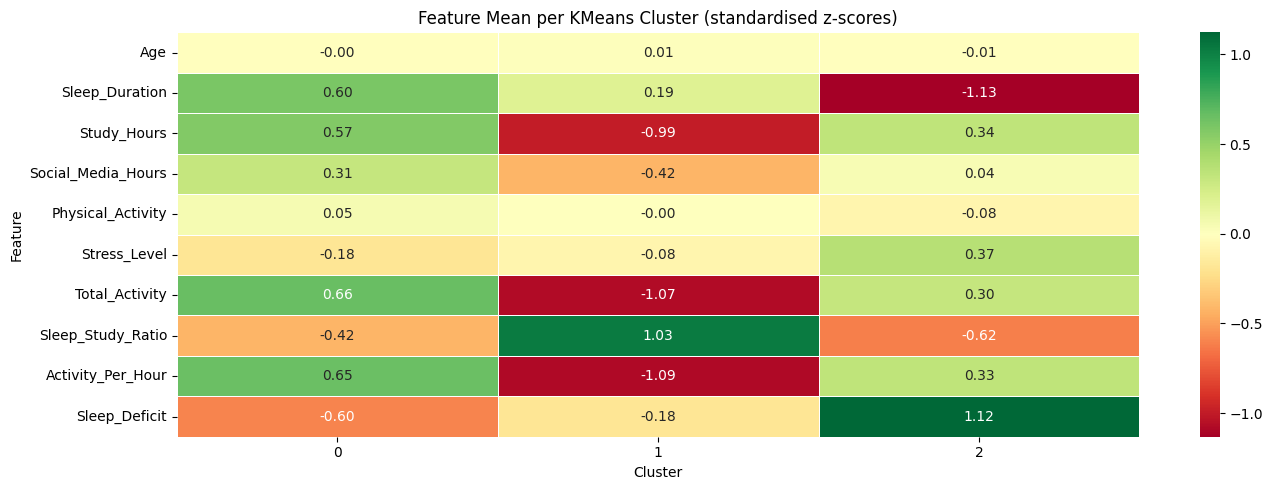

In [17]:
# Cluster size bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KMeans: count how many points fall in each cluster
km_counts = pd.Series(labels_kmeans).value_counts().sort_index()
axes[0].bar(km_counts.index.astype(str), km_counts.values, color='steelblue')
axes[0].set_title('KMeans – Cluster Sizes')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of students')

# DBSCAN: rename -1 to "Noise" so the chart is readable
db_labels = ['Noise' if l == -1 else str(l) for l in labels_dbscan]
db_counts = pd.Series(db_labels).value_counts()
axes[1].bar(db_counts.index, db_counts.values, color='coral')
axes[1].set_title('DBSCAN – Cluster Sizes (including noise)')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Number of students')

plt.tight_layout()
plt.savefig('Unsupervised_Learning/plots/cluster_sizes.png', dpi=150)
plt.show()

# Feature mean heatmap
# Take the scaled feature matrix, add cluster labels, group and average
df_heatmap = df_model.copy()
df_heatmap['Cluster'] = labels_kmeans
cluster_means = df_heatmap.groupby('Cluster').mean()
# Result: a table where rows = clusters, columns = features, values = mean z-score

plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_means.T,    # .T = transpose so features are rows, clusters are columns
    annot=True,         # show the actual numbers inside each cell
    fmt='.2f',          # 2 decimal places
    cmap='RdYlGn',      # Red = low, Yellow = middle, Green = high
    center=0,           # 0 is the middle of the color scale (makes sense for z-scores)
    linewidths=0.5      # thin lines between cells
)
plt.title('Feature Mean per KMeans Cluster (standardised z-scores)')
plt.ylabel('Feature')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('Unsupervised_Learning/plots/feature_heatmap.png', dpi=150)
plt.show()

## Cluster Interpretation & Profiles

With K=3 selected, we now profile each cluster by examining the mean feature values
(z-scores) per cluster and relating them to student lifestyle patterns and depression risk.

In [18]:
# Load clustering results
df_results = pd.read_csv('Unsupervised_Learning/clustering_results/clustering_results.csv')

numeric_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
                'Physical_Activity', 'Stress_Level', 'Total_Activity',
                'Sleep_Study_Ratio', 'Activity_Per_Hour', 'Sleep_Deficit']

cluster_means = df_results.groupby('Cluster_KMeans')[numeric_cols].mean().round(3)
cluster_sizes = df_results['Cluster_KMeans'].value_counts().sort_index()
depression_rate = df_results.groupby('Cluster_KMeans')['Depression'] \
                             .apply(lambda x: (x == True).mean()).round(4) * 100

print('Cluster sizes:')
print(cluster_sizes)
print()
print('Depression rate per cluster (%):')
print(depression_rate.round(2))
print()
print('Mean feature values per cluster (z-scores):')
print(cluster_means.to_string())

Cluster sizes:
Cluster_KMeans
0    18204
1    22742
2    15058
Name: count, dtype: int64

Depression rate per cluster (%):
Cluster_KMeans
0     9.67
1     8.99
2    10.92
Name: Depression, dtype: float64

Mean feature values per cluster (z-scores):
                  Age  Sleep_Duration  Study_Hours  Social_Media_Hours  Physical_Activity  Stress_Level  Total_Activity  Sleep_Study_Ratio  Activity_Per_Hour  Sleep_Deficit
Cluster_KMeans                                                                                                                                                              
0               0.014           0.160       -1.004              -0.425             -0.013        -0.065          -1.082              1.038             -1.099         -0.156
1              -0.018           0.609        0.556               0.299              0.052        -0.185           0.638             -0.402              0.633         -0.608
2               0.001          -1.129        0.356         

### Cluster 0 — Sedentary Low-Study Students (n = 18,204 | 33.1%)

**Defining traits:** Lowest study hours (z = −1.00) and lowest physical activity (z = −1.08) of all
clusters. Sleep is slightly above average, and the sleep-to-study ratio is the highest (z = +1.04),
meaning sleep time dominates over study time. Stress is near average.

**Domain interpretation:** These students are disengaged from both academics and physical activity.
While they are not acutely stressed, their sedentary and low-effort lifestyle represents a passive
risk factor. Depression rate: **9.67%** (moderate risk).

---

### Cluster 1 — Balanced Active Students (n = 22,742 | 41.3%)

**Defining traits:** Above-average study hours (z = +0.56) and physical activity (z = +0.64),
above-average sleep duration (z = +0.61), the lowest sleep deficit (z = −0.61) and the lowest
stress level (z = −0.19) of all clusters.

**Domain interpretation:** This is the healthiest student group. They sustain academic performance
without sacrificing sleep or wellbeing. This cluster is the reference low-risk profile.
Depression rate: **8.99%** (lowest — low risk).

---

### Cluster 2 — Sleep-Deprived High-Stress Students (n = 15,058 | 27.4%)

**Defining traits:** Least sleep of all clusters (z = −1.13), highest sleep deficit (z = +1.12),
highest stress level (z = +0.37), and above-average study hours (z = +0.36). They are studying
hard but at the cost of sleep.

**Domain interpretation:** These students are over-extended — high academic load is creating sleep
deprivation and stress accumulation. This is the highest-risk group and the primary target for
intervention-focused advice.
Depression rate: **10.92%** (highest — high risk).

## Integration Strategy

This section explains how the KMeans cluster assignments enhance the advice system
across three integration points: supervised learning, Generative AI prompts, and
real-time user routing.

### How Clusters Enhance the System

The three clusters map to interpretable risk levels:

| Cluster | Label | Risk Level | Depression Rate |
|---------|-------|------------|-----------------|
| 0 | Sedentary Low-Study | Moderate | 9.67% |
| 1 | Balanced Active | Low | 8.99% |
| 2 | Sleep-Deprived High-Stress | High | 10.92% |

---

### Integration Point 1: Cluster Label as Additional Feature in Supervised Models

The `Cluster_KMeans` label (0, 1, or 2) can be appended to the feature matrix before
training the supervised classifiers (Logistic Regression, Random Forest, SVM). Cluster
membership encodes a compact summary of the student's overall lifestyle pattern — information
that may not be fully captured by individual features alone.

**Expected benefit:** The supervised model gains a pre-computed lifestyle context signal,
which may improve precision for borderline depression predictions where individual features
alone are ambiguous.

---

### Integration Point 2: Cluster-Aware Generative AI Prompts

When a student's input is passed to the Generative AI component, the cluster label and
profile are included in the prompt context alongside the supervised model's prediction.
This allows the AI to generate personalised, risk-level-appropriate advice.

Prompt context example:
```
Student profile:
  - Supervised model prediction: Depression = True
  - Lifestyle cluster: Cluster 2 (Sleep-Deprived High-Stress)
  - Cluster characteristics: lowest sleep, highest stress, high study load

Generate personalised advice focused on sleep hygiene and stress management.
```

Without the cluster, the Gen AI receives only a binary prediction. With the cluster,
it knows *why* the student is at risk and can tailor the advice accordingly.

**Expected benefit:** Advice becomes actionable and specific rather than generic.
Cluster 2 students receive sleep/stress advice; Cluster 0 students receive
engagement and activity advice; Cluster 1 students receive positive reinforcement.

---

### Integration Point 3: Risk-Level Routing Before Supervised Prediction

As a lightweight pre-screening step, a new student's features can be assigned to a
cluster using the saved KMeans model before running the full supervised classifier.
If the student falls in Cluster 2, the system can flag them for priority review even
before the final binary prediction is made, since Cluster 2 carries the highest
depression prevalence.

**Expected benefit:** Faster, two-stage risk assessment — cluster-based triage first,
then supervised classification for confirmation.

### Cluster Relationship with Supervised Predictions

To ground the integration strategy in evidence this subsection (a) analyses the
alignment between KMeans cluster assignments and the ground-truth `Depression` label
via a cross-tabulation, and (b) runs a controlled experiment to quantify the effect
of appending `Cluster_KMeans` as an additional feature to the best supervised model
(Random Forest with `class_weight='balanced'`, matching Phase 1 configuration).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_cl = pd.read_csv('Unsupervised_Learning/clustering_results/clustering_results.csv')
df_cl['Depression_int'] = df_cl['Depression'].astype(int)

# --- Cross-tabulation (counts) ---
crosstab = pd.crosstab(
    df_cl['Cluster_KMeans'], df_cl['Depression'],
    rownames=['Cluster'], colnames=['Depression']
)
crosstab.index = ['Cluster 0 (Sedentary)', 'Cluster 1 (Balanced)', 'Cluster 2 (Sleep-Deprived)']
print('Cross-tabulation (counts):')
print(crosstab)
print()

# --- Depression rate per cluster ---
dep_rate = df_cl.groupby('Cluster_KMeans')['Depression_int'].mean().mul(100).round(2)
labels_map = {0: 'Sedentary Low-Study', 1: 'Balanced Active', 2: 'Sleep-Deprived High-Stress'}
print('Depression rate per cluster (%):')
for cl, rate in dep_rate.items():
    print(f'  Cluster {cl} ({labels_map[cl]}): {rate:.2f}%')

# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

crosstab_pct = pd.crosstab(
    df_cl['Cluster_KMeans'], df_cl['Depression'], normalize='index'
).mul(100)
crosstab_pct.index = ['Cluster 0\n(Sedentary)', 'Cluster 1\n(Balanced)', 'Cluster 2\n(Sleep-Deprived)']
sns.heatmap(
    crosstab_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
    xticklabels=['Not Depressed', 'Depressed'], ax=axes[0]
)
axes[0].set_title('Cluster × Depression Label (%)', fontsize=11)
axes[0].set_xlabel('Depression')
axes[0].set_ylabel('')

colors = ['#f0a500', '#2ecc71', '#e74c3c']
axes[1].bar(
    ['Cluster 0\n(Sedentary)', 'Cluster 1\n(Balanced)', 'Cluster 2\n(Sleep-Deprived)'],
    dep_rate.values, color=colors
)
axes[1].set_ylim(0, 15)
axes[1].set_ylabel('Depression Rate (%)')
axes[1].set_title('Depression Rate per Cluster (%)', fontsize=11)
for j, v in enumerate(dep_rate.values):
    axes[1].text(j, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('Unsupervised_Learning/plots/cluster_depression_crosstab.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: Unsupervised_Learning/plots/cluster_depression_crosstab.png')

#### Cross-tabulation Interpretation

| Cluster | Label | Depression Rate | Risk Level |
|---------|-------|-----------------|------------|
| 0 | Sedentary Low-Study | 9.67% | Moderate |
| 1 | Balanced Active | 8.99% | Low (reference) |
| 2 | Sleep-Deprived High-Stress | 10.92% | High |

- **Cluster 1 (Balanced Active)** has the lowest depression rate, consistent with its
  healthy sleep, activity, and study balance — confirming it as the low-risk reference.
- **Cluster 2 (Sleep-Deprived High-Stress)** carries the highest depression rate and is
  the primary target for intervention-focused advice.
- The absolute spread across clusters is ~2 percentage points. This small range confirms
  that **cluster membership alone is not sufficient for classification** — the clusters
  capture lifestyle archetypes, not sharp risk boundaries.

> **Key finding:** Clustering acts as a **context and personalization layer** — it explains
> *why* a student may be at risk and what type of advice to generate, while the supervised
> model determines *whether* the student is at risk. The two components are complementary,
> not interchangeable.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load aligned dataset (clustering results contain features + Depression + Cluster_KMeans)
df_exp = pd.read_csv('Unsupervised_Learning/clustering_results/clustering_results.csv')
df_exp['y'] = df_exp['Depression'].astype(int)

drop_cols = ['Depression', 'y', 'Cluster_DBSCAN']
X_base     = df_exp.drop(columns=drop_cols + ['Cluster_KMeans'])  # 18 features, no cluster
X_enhanced = df_exp.drop(columns=drop_cols)                        # 19 features, +Cluster_KMeans
y_exp = df_exp['y']

# Identical split for both configurations
X_tr_b, X_te_b, y_tr, y_te = train_test_split(X_base,     y_exp, test_size=0.2,
                                                random_state=42, stratify=y_exp)
X_tr_e, X_te_e, _,    _    = train_test_split(X_enhanced, y_exp, test_size=0.2,
                                                random_state=42, stratify=y_exp)

# Random Forest matching Phase 1 configuration
rf_exp = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                class_weight='balanced', random_state=42, n_jobs=-1)

def get_metrics(yt, yp, label):
    return {
        'Configuration': label,
        'Accuracy':  round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall':    round(recall_score(yt, yp, zero_division=0), 4),
        'F1-Score':  round(f1_score(yt, yp, zero_division=0), 4),
    }

rf_exp.fit(X_tr_b, y_tr)
y_pred_base = rf_exp.predict(X_te_b)

rf_exp.fit(X_tr_e, y_tr)
y_pred_enh  = rf_exp.predict(X_te_e)

exp_results = pd.DataFrame([
    get_metrics(y_te, y_pred_base, 'Without Cluster_KMeans (baseline)'),
    get_metrics(y_te, y_pred_enh,  'With Cluster_KMeans (+cluster feature)'),
]).set_index('Configuration')

print(exp_results.to_string())
print()

delta = (exp_results.loc['With Cluster_KMeans (+cluster feature)']
         - exp_results.loc['Without Cluster_KMeans (baseline)']).round(4)
print('Delta (With − Without):')
for metric, val in delta.items():
    sign = '+' if val >= 0 else ''
    print(f'  {metric:<12}: {sign}{val}')

#### Experiment Interpretation

| Configuration | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Without Cluster_KMeans | 0.7445 | 0.2084 | 0.5807 | 0.3067 |
| With Cluster_KMeans | 0.7419 | 0.2068 | 0.5826 | 0.3052 |
| **Delta** | −0.0026 | −0.0016 | +0.0019 | −0.0015 |

Adding `Cluster_KMeans` as a feature produces **no meaningful change** in any metric
(all deltas < 0.003). This is expected for two reasons:

1. **Redundancy:** The cluster label is derived from the same features the model already
   receives (Sleep_Duration, Study_Hours, Stress_Level, etc.), so it carries no new
   information for the tree.
2. **Weak cluster signal:** The silhouette score of 0.171 reflects substantial cluster
   overlap, so the cluster label is a noisy approximation of patterns the model can
   already detect directly.

**Conclusion:** The cluster feature does not improve predictive performance, and the
supervised classifier should remain the primary depression-risk decision mechanism.
The value of `Cluster_KMeans` lies entirely in **interpretability and personalization**:
it provides a human-readable lifestyle archetype that can be passed to the Generative AI
prompt to generate cluster-appropriate, actionable advice — a role the binary prediction
label alone cannot fulfil.

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib, os

# Re-fit KMeans on the clean numeric data so we can demonstrate prediction on new input
df_base = pd.read_csv('Dataset/clean_data.csv', low_memory=False)
numeric_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
                'Physical_Activity', 'Stress_Level', 'Total_Activity',
                'Sleep_Study_Ratio', 'Activity_Per_Hour', 'Sleep_Deficit']
df_num = df_base[numeric_cols].dropna()

scaler = StandardScaler()
X_fit = scaler.fit_transform(df_num)

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_fit)

# Save model for use by supervised and Gen AI components
os.makedirs('Unsupervised_Learning', exist_ok=True)
joblib.dump(kmeans_final, 'Unsupervised_Learning/kmeans_model.pkl')
joblib.dump(scaler,       'Unsupervised_Learning/kmeans_scaler.pkl')
print('Saved: Unsupervised_Learning/kmeans_model.pkl')
print('Saved: Unsupervised_Learning/kmeans_scaler.pkl')

# --- Demonstrate: predict cluster for a new student ---
cluster_names = {
    0: 'Sedentary Low-Study (Moderate Risk)',
    1: 'Balanced Active (Low Risk)',
    2: 'Sleep-Deprived High-Stress (High Risk)'
}

# Example: a student with high stress, low sleep, high study hours
new_student = pd.DataFrame([{
    'Age': 21, 'Sleep_Duration': 4.5, 'Study_Hours': 9,
    'Social_Media_Hours': 3, 'Physical_Activity': 1,
    'Stress_Level': 8, 'Total_Activity': 10, 'Sleep_Study_Ratio': 0.5,
    'Activity_Per_Hour': 1.1, 'Sleep_Deficit': 3.5
}])

new_scaled = scaler.transform(new_student)
predicted_cluster = kmeans_final.predict(new_scaled)[0]
print(f'\nExample student cluster: {predicted_cluster} — {cluster_names[predicted_cluster]}')

Saved: Unsupervised_Learning/kmeans_model.pkl
Saved: Unsupervised_Learning/kmeans_scaler.pkl

Example student cluster: 1 — Balanced Active (Low Risk)


## Challenges & Limitations

### 1. Weak Cluster Separation
The KMeans silhouette score of 0.171 indicates that clusters overlap considerably in the
feature space. Student lifestyle patterns exist on a continuum rather than as discrete groups,
so cluster boundaries are inherently soft. This limits the confidence with which a single
student can be assigned to one cluster.

### 2. DBSCAN Found Only One Cluster
DBSCAN with eps=1.5 collapsed almost all 55,004 students into a single cluster (only 2 noise
points). This reflects that student lifestyle data is densely and relatively uniformly
distributed — there are no truly isolated high-density islands. DBSCAN is therefore not
suitable for integration in this dataset.

### 3. Small Differences in Depression Rate Across Clusters
Depression rates across the three clusters range from 8.99% to 10.92% — a difference of
less than 2 percentage points. This suggests that cluster membership alone is not a strong
predictor of depression. The clusters capture lifestyle archetypes but not sharp risk
boundaries. Supervised learning remains the primary classification mechanism.

### 4. Engineered Features Inflate Feature Space
Several features used in clustering (Total_Activity, Sleep_Study_Ratio, Activity_Per_Hour,
Sleep_Deficit) were derived from base features. This means the clustering is partially
influenced by the same underlying variables multiple times, which can bias the cluster
shapes toward dimensions where engineered features happen to amplify variance.

### 5. Cluster Labels Are Not Stable Across Runs
KMeans cluster numbering (0, 1, 2) is arbitrary and may change between runs with different
random seeds. The saved model (`kmeans_model.pkl`) must be used consistently to ensure
that cluster labels remain comparable across the supervised and Gen AI components.